In [19]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import umap
import plotly.graph_objects as go
from scipy.spatial import KDTree
import torch

In [20]:
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    device = "cuda"
else:
    print("No GPU found, using CPU.")
    device = "cpu"

Using GPU: NVIDIA GeForce RTX 4080 SUPER


In [21]:
df = pd.read_csv("data/raw/movies.csv")
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [22]:
list(df.columns)

['names',
 'date_x',
 'score',
 'genre',
 'overview',
 'crew',
 'orig_title',
 'status',
 'orig_lang',
 'budget_x',
 'revenue',
 'country']

In [23]:
placeholder_text = "We don't have an overview translated in English. Help us expand our database by adding one."
df = df[df["overview"] != placeholder_text]

df["genre"] = df["genre"].fillna("Unknown")

duplicate_cols = ["names", "date_x"]

df = df.groupby(duplicate_cols).agg({
    "score": "mean",              # average scores
    "genre": "first",             # keep first genre string
    "overview": "first",          # keep first overview
    "crew": "first",              # keep first crew info
    "orig_title": "first",        # keep original title
    "status": "first",            # keep first status
    "orig_lang": "first",         # keep original language
    "budget_x": "sum",            # sum budgets
    "revenue": "sum",             # sum revenues
    "country": "first"            # keep first country
}).reset_index()

<Axes: >

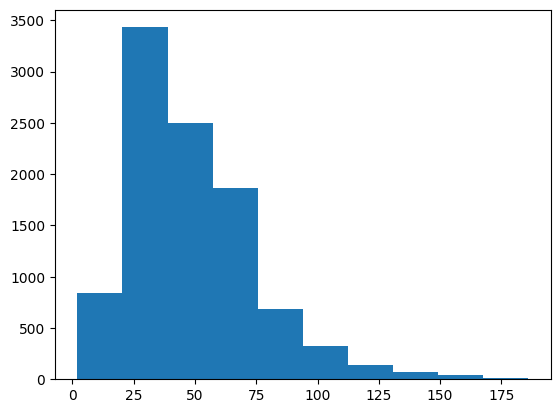

In [24]:
lens = df["overview"].apply(str.split).apply(len)
lens.hist(grid=False)

In [25]:

def textify_movie(row):
    def clean(val):
        if pd.isna(val) or val == '':
            return "Unknown"
        return str(val)

    # Grab the goods
    name = clean(row.get('names'))
    date = clean(row.get('date_x'))
    score = clean(row.get('score'))
    genres = clean(row.get('genre'))
    overview = clean(row.get('overview'))
    crew = clean(row.get('crew'))
    lang = clean(row.get('orig_lang'))
    budget = clean(row.get('budget_x'))
    rev = clean(row.get('revenue'))
    country = clean(row.get('country'))

    # Assemble the mega-string
    text = f"Title: {name}. Released in {date}, this {country} film is primarily in {lang}. "
    text += f"It falls under the {genres} genre. "
    text += f"It holds a rating of {score}/100. "
    text += f"Financially, it had a budget of ${budget} and made ${rev} in revenue. "
    text += f"Plot overview: {overview} "
    text += f"Key crew members include: {crew}."

    return text

df['content'] = df.apply(textify_movie, axis=1)

In [26]:
model = SentenceTransformer("BAAI/bge-small-en-v1.5")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10825.34it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
embeddings = model.encode(
    df["content"].tolist(), 
    device=device,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches: 100%|██████████| 310/310 [00:10<00:00, 29.48it/s]


In [28]:
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    #random_state=42     # Uncomment for reproducibility, currently left out for speed
)
coords = reducer.fit_transform(embeddings)

In [29]:
coords.shape

(9910, 3)

In [30]:
# Map genres to integers
genre_to_num = {g: i for i, g in enumerate(df["genre"].unique())}
color_nums = df["genre"].map(genre_to_num)

# Create 3D scatter using Scatter3d for better control
fig = go.Figure(
    go.Scatter3d(
        x=coords[:, 0],
        y=coords[:, 1],
        z=coords[:, 2],
        mode='markers',  # ONLY markers
        marker=dict(
            size=2,        # small markers
            opacity=0.8,
            color=color_nums,  # color by genre
        ),
        text=df["names"],  # hover text
    )
)

# Layout settings
fig.update_layout(
    width=1200,
    height=800,
    scene=dict(
        aspectmode='data'
    ),
    template="plotly_dark",
)

fig.show()

In [31]:
df[["x", "y", "z"]] = coords
coords

array([[ 5.329479 ,  6.0098934,  9.763924 ],
       [ 3.1108155, 11.960919 ,  7.4329543],
       [ 3.2566867, 11.206281 , 10.324124 ],
       ...,
       [ 2.115141 , 10.639457 ,  9.9765835],
       [ 4.451501 ,  7.6221995,  9.562692 ],
       [ 2.4993021,  5.9193215,  8.485648 ]],
      shape=(9910, 3), dtype=float32)

In [32]:
tree = KDTree(coords)

In [33]:
def get_closest_movies(movie_name, df, tree, n=5):
    if movie_name not in df['names'].values:
        return "Movie not found, check your spelling."

    idx = df[df['names'] == movie_name].index[0]
    target_xyz = df.loc[idx, ['x', 'y', 'z']].values

    distances, indices = tree.query(target_xyz, k=n + 1)

    # skipping the first one, which is the reference movie
    neighbor_indices = indices[1:]

    return df.iloc[neighbor_indices]

In [34]:
get_closest_movies("Tenet", df, tree).head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,content,x,y,z
9155,"Tomorrow, When the War Began",08/08/2010,62.0,"Action, Adventure, Drama","Ellie Linton, a teen from an Australian coasta...","Caitlin Stasey, Ellie Linton, Rachel Hurd-Wood...","Tomorrow, When the War Began",Released,English,27000000.0,16504936.0,AU,"Title: Tomorrow, When the War Began. Released ...",2.130938,11.248896,10.214853
6972,Stealth,09/08/2005,53.0,"Science Fiction, Action, War",Deeply ensconced in a top-secret military prog...,"Josh Lucas, Ben Gannon, Jessica Biel, Kara Wad...",Stealth,Released,English,138000000.0,76416746.0,AU,"Title: Stealth. Released in 09/08/2005 , this ...",2.215137,11.333290,10.374881
3739,Inception,07/22/2010,84.0,"Action, Science Fiction, Adventure","Cobb, a skilled thief who commits corporate es...","Leonardo DiCaprio, Dom Cobb, Joseph Gordon-Lev...",Inception,Released,English,160000000.0,728537960.0,AU,"Title: Inception. Released in 07/22/2010 , thi...",2.184014,11.503903,10.212087
9178,Total Recall,09/06/2012,60.0,"Action, Science Fiction, Thriller","Welcome to Rekall, the company that can turn y...","Colin Farrell, Douglas Quaid / Hauser, Kate Be...",Total Recall,Released,English,190000000.0,473255918.0,AU,"Title: Total Recall. Released in 09/06/2012 , ...",2.370193,11.390180,10.120408
1185,Blood Red Sky,07/23/2021,70.0,"Horror, Thriller, Action",A woman with a mysterious illness is forced in...,"Peri Baumeister, Nadja, Carl Anton Koch, Elias...",Blood Red Sky,Released,German,17739525.0,224582523.6,AU,"Title: Blood Red Sky. Released in 07/23/2021 ,...",2.345381,11.144477,10.280662


In [ ]:
df.to_csv("data/processed/with_embeddings.csv")